# Description
In this Jupyter notebook, we will briefly explore the data, and generate trading strategies based on forecasts made by AR(1) models for each instrument independently. We will introduce 4 different strategies that are somewhat similar, in that they depend on the AR(1) forecast to instantiate positions.

# Import

In [1]:
# Standard library imports
import datetime as dt
import os
import sys

# Third party imports
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
plt.style.use("seaborn-v0_8")
from statsmodels.tsa.stattools import adfuller

# Local imports
from utilities import (simple_returns, log_returns, directional_positions, cross_sectional_positions, position_returns, date_returns, calculate_sr, calculate_wealth, cum_simple_wealth, cum_log_wealth, adf_fuller_test, multiple_adf_tests)
from ar_script import rolling_ar_forecast
from ar_script import multiple_forecasts
from ar_script import multiple_scores
from ar_script import rolling_regression, multiple_apply_regression

# Data Analysis

In [2]:
df_train = pd.read_csv('df_train.csv')

In [3]:
df_train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
1,2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2,2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
3,2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
4,2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991


In [4]:
df_train.tail()

,date,symbol,open,close,low,high,volume
100595,2013-12-31,XTG,20.15,20.00,20.15,20.15,42044.703
100596,2013-12-31,YPN,14.94,14.82,14.94,14.94,29030.106
100597,2013-12-31,YRD,3.40,3.39,3.40,3.40,11778.336
100598,2013-12-31,YVNL,4.25,4.24,4.25,4.25,6431.843
100599,2013-12-31,ZQN,32.01,32.04,32.01,32.01,54319.469


In [5]:
df_train.shape

(100600, 7)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100600 entries, 0 to 100599
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    100600 non-null  object 
 1   symbol  100600 non-null  object 
 2   open    100600 non-null  float64
 3   close   100600 non-null  float64
 4   low     100600 non-null  float64
 5   high    100600 non-null  float64
 6   volume  100600 non-null  float64
dtypes: float64(5), object(2)
memory usage: 5.4+ MB


In [7]:
# Unique symbols
print('Number of unique symbols:', len(df_train['symbol'].unique()))
print('Number of unique dates:', len(df_train['date'].unique()))

Number of unique symbols: 100
Number of unique dates: 1006


In [8]:
df_train_wide = df_train.pivot(index='date', values='close', columns='symbol')
df_train_wide.index = pd.to_datetime(df_train_wide.index)
df_train_wide = df_train_wide.sort_index()

In [9]:
print("Total null values:", df_train_wide.isna().sum().sum())

Total null values: 0


In [10]:
# Summary statistics
df_train_wide.describe()

symbol,ACTS,AMWD,ARV,BBY,BCDM,BZK,BZQM,CDM,CDRX,CLYQ,...,WYLR,WZB,XBRQ,XFG,XPT,XTG,YPN,YRD,YVNL,ZQN
count,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,...,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.00000
mean,14.077087,8.004970,18.001382,2.724473,20.434463,15.859861,45.251769,10.887932,15.543757,2.452187,...,12.670805,6.507097,6.060924,18.747684,70.564215,18.543280,12.897783,4.293101,2.475835,25.14830
std,1.847735,1.227604,2.517147,0.320843,3.058197,2.410707,4.933455,1.370540,3.697120,0.230995,...,1.677963,0.770862,1.947529,2.655176,12.242660,1.894617,1.757839,0.727431,0.512197,2.58555
min,10.280000,5.380000,12.830000,2.160000,14.720000,11.350000,32.740000,8.100000,9.950000,1.860000,...,8.470000,4.800000,2.830000,13.030000,44.860000,14.190000,9.380000,2.210000,1.310000,19.57000
25%,12.700000,7.040000,16.457500,2.480000,18.077500,14.052500,42.177500,9.760000,12.450000,2.270000,...,11.560000,5.960000,4.180000,16.862500,60.425000,17.262500,11.532500,3.920000,2.120000,23.48250
50%,14.160000,7.895000,17.770000,2.660000,20.095000,15.560000,45.160000,10.590000,14.270000,2.450000,...,12.540000,6.340000,6.195000,18.590000,70.065000,18.735000,12.780000,4.330000,2.540000,25.15500
75%,14.970000,8.820000,18.887500,2.950000,22.290000,17.430000,48.165000,12.250000,18.600000,2.620000,...,13.890000,6.970000,7.487500,20.210000,77.745000,19.667500,13.917500,4.820000,2.760000,26.72750
max,19.910000,11.170000,29.870000,3.600000,29.770000,22.570000,57.940000,14.070000,23.570000,3.110000,...,16.880000,9.150000,11.250000,26.750000,102.610000,23.950000,17.350000,5.860000,4.240000,32.23000


In [11]:
# Split into train-test sets
df_train_start = df_train_wide[df_train_wide.index >= "2011-07-01"]

In [12]:
K_STEP_RETURNS = 1

In [13]:
# Calculate log returns
df_train_log_returns = log_returns(df_train_start, K_STEP_RETURNS, False)
# Calculate simple returns
df_train_simple_returns = simple_returns(df_train_start, K_STEP_RETURNS, False)

In [14]:
# Identify symbols
symbols = sorted(df_train['symbol'].unique().tolist())

In [16]:
# Test for returns stationarity using ADF test
adf_res = multiple_adf_tests(df_train_simple_returns,
                             symbols,
                             "1%")

In [17]:
adf_res[adf_res['stationary']]

,symbol,test_statistic,p_value,lags_used,number_observations,critical_value,stationary
0,ACTS,-15.036432,9.733747e-28,2,625,-3.440856,True
1,AMWD,-14.978615,1.171125e-27,2,625,-3.440856,True
2,ARV,-12.458746,3.443704e-23,5,622,-3.440907,True
3,BBY,-11.853946,7.100502e-22,4,623,-3.440890,True
4,BCDM,-6.279480,3.827677e-08,9,618,-3.440976,True
...,...,...,...,...,...,...,...
95,XTG,-12.335131,6.298083e-23,3,624,-3.440873,True
96,YPN,-5.669461,8.991850e-07,16,611,-3.441098,True
97,YRD,-11.396722,7.825621e-21,3,624,-3.440873,True
98,YVNL,-11.281833,1.449790e-20,4,623,-3.440890,True


It seems that the simple returns of all the instruments are stationary, according to the ADF test. Therefore, we can safely fit an AR(1) model on returns.

### AR(1) forecasts

In [18]:
# Calculate AR(1) forecasts for simple returns - no intercept
ar1_simple_rets_forecasts = multiple_forecasts(df_train_simple_returns, 
                                               symbols, AutoReg, 126, 
                                               K_STEP_RETURNS, lags=[1], trend='n')
# Calculate R2 scores
ar1_simple_rets_r2 = multiple_scores(ar1_simple_rets_forecasts, 
                                     symbols, r2_score, 'r2')

In [42]:
from statsmodels.tsa.api import VAR
dat = np.array(df_train_simple_returns)
model_vr = VAR(dat)
res = model_vr.fit(1)
res.forecast(dat[-1:], 2)[0]

array([ 0.00232209, -0.00269149,  0.00317396,  0.00057747, -0.00419902,
        0.0014765 ,  0.00159249,  0.00617098, -0.00949693,  0.00518982,
       -0.00592711,  0.00294371, -0.00559152,  0.01574659, -0.01826482,
        0.00512433,  0.02073361,  0.00415365,  0.00689713, -0.00172899,
        0.00160235,  0.00655634, -0.0014356 , -0.00133832,  0.00068033,
        0.00100339,  0.00454541,  0.00091847,  0.00207729,  0.00942154,
       -0.00486876,  0.00161169, -0.00694798,  0.00168241, -0.00146331,
       -0.00045976, -0.00438968, -0.00433711, -0.00441532, -0.00596388,
       -0.00116753,  0.00262809,  0.00036541, -0.00201825, -0.00272107,
       -0.00199932,  0.00725571, -0.00097179, -0.00178306,  0.00056931,
       -0.00028901, -0.00151498,  0.00834715, -0.00082586,  0.00107305,
        0.00354435, -0.00306071, -0.00411102,  0.00924617,  0.0011256 ,
        0.00491626,  0.00857138, -0.00356238,  0.00253091, -0.00532844,
        0.0034814 ,  0.00079819,  0.00742969, -0.00683453,  0.01

In [19]:
# Concatenate to have a long dataframe
new_names_forecasts = []
for i, curr_symbol in enumerate(symbols):
    curr_forecast = ar1_simple_rets_forecasts[i]
    curr_renamed_forecast = curr_forecast.copy().rename(columns={curr_symbol: 'return'}) # Rename the symbol return column to return for concatenation
    curr_renamed_forecast['symbol'] = curr_symbol # Create symbol column to difference between instruments
    curr_renamed_forecast['forward_return'] = curr_renamed_forecast['return'].shift(-K_STEP_RETURNS) # Forward returns for position assignment based on residuals
    new_names_forecasts.append(curr_renamed_forecast)
all_forecasts = pd.concat(new_names_forecasts, axis=0).sort_index().dropna() # Nan's were introduced by calculating forward returns


In [20]:
all_forecasts

,forecast,return,symbol,forward_return
date,,,,
2012-01-03,-0.000496,0.034215,ACTS,-0.006015
2012-01-03,-0.000644,0.034506,GZLT,-0.024108
2012-01-03,-0.000064,0.014019,XPT,0.000790
2012-01-03,-0.000347,0.003947,HCLF,0.009174
2012-01-03,-0.001371,0.025974,HJC,-0.003617
...,...,...,...,...
2013-12-30,-0.007355,0.014615,HNTV,0.019712
2013-12-30,0.001497,-0.002165,SYDR,0.037613
2013-12-30,-0.001657,0.012486,TPLF,0.001121


### Strategy 1: Directional AR(1) positions
In this strategy we use the forecasted value of each instrument to instantiate directional positions. Specifically, we go long asset i at time t if the predicted value is positive, otherwise we go short, with arbitrary tie breaking since we don't care when forecasted values are 0. 

In [21]:
# Instantiate directional positions
ar1_forecast_direct = directional_positions(all_forecasts, 'forecast', 100)

# Calculate return summaries
ar1_forecast_pos_return = position_returns(ar1_forecast_direct, 'weight', 'return')
ar1_forecast_date_rets = date_returns(ar1_forecast_pos_return, 'positions_return')
ar1_forecast_wealth = calculate_wealth(ar1_forecast_date_rets, 'positions_return')
ar1_forecast_log_w = cum_log_wealth(ar1_forecast_wealth, 'wealth')
ar1_forecast_simple_w = cum_simple_wealth(ar1_forecast_log_w, 'wealth')
ar1_forecast_sr = calculate_sr(ar1_forecast_date_rets, 'positions_return')
print("Daily SR on directional positions: ", ar1_forecast_sr)

Daily SR on directional positions:  0.05148950334509125


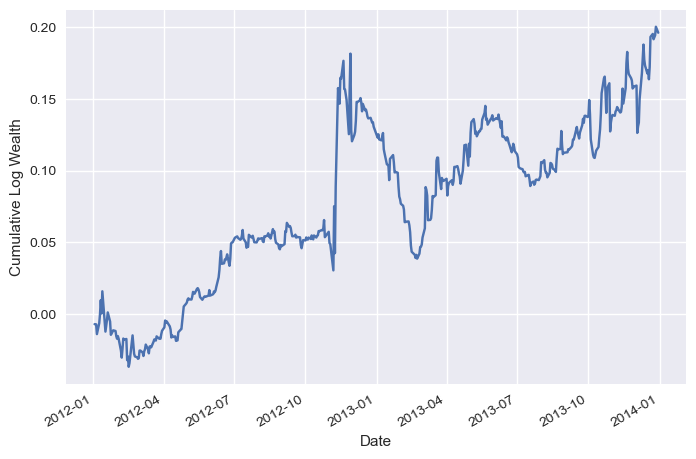

In [22]:
ar1_forecast_simple_w['log_cum_wealth'].plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Log Wealth')
plt.show()

### Strategy 2: Cross-sectional AR(1) positions
In this strategy we will use the forecasted values of each instrument returns to instantiate cross-sectional positions. Specifically, we will rank each instrument by the forecasted value, and we will go long the top k instruments with the largest forecasted values, and short the bottom k instruments with the lowest forecasted values. Initially, $k=5$.

In [23]:
# Instantiate cross-sectional positions
ar1_forecast_cross = cross_sectional_positions(all_forecasts, 'forecast', 2)

# Calculate returns summaries
ar1_forecast_cross_ret = position_returns(ar1_forecast_cross, 'weight', 'return')
ar1_forecast_cross_date_rets = date_returns(ar1_forecast_cross_ret, 'positions_return')
ar1_forecast_cross_sr = calculate_sr(ar1_forecast_cross_date_rets, 'positions_return')
ar1_cross_wealth = calculate_wealth(ar1_forecast_cross_date_rets, 'positions_return')
ar1_cross_log_w = cum_log_wealth(ar1_cross_wealth, 'wealth')
ar1_cross_simple_w = cum_simple_wealth(ar1_cross_log_w, 'wealth')
print("Daily SR on cross-sectional positions", ar1_forecast_cross_sr * np.sqrt(252))

Daily SR on cross-sectional positions 3.802749024266051


In [24]:
ar1_cross_simple_w

,positions_return,wealth,log_cum_wealth,cum_wealth
date,,,,
2012-01-03,0.000499,1.000499,0.000499,1.000499
2012-01-04,0.014481,1.014481,0.014876,1.014987
2012-01-05,0.022340,1.022340,0.036970,1.037662
2012-01-06,-0.001092,0.998908,0.035877,1.036529
2012-01-09,-0.014793,0.985207,0.020974,1.021195
...,...,...,...,...
2013-12-23,-0.000310,0.999690,2.257357,9.557796
2013-12-24,-0.010380,0.989620,2.246923,9.458587
2013-12-26,0.006305,1.006305,2.253208,9.518221


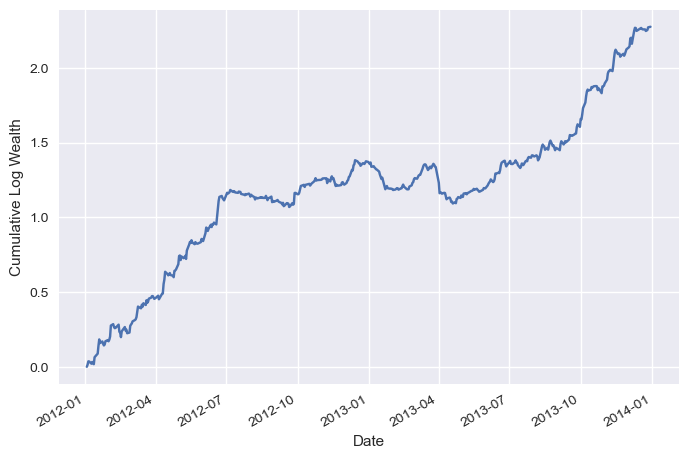

In [25]:
ar1_cross_simple_w['log_cum_wealth'].plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Log Wealth')
plt.show()

### Strategy 3: Cross sectional positions based on residuals
In this strategy, we will calculate the residuals from the AR(1) forecasts. That is, we have forecasted $R_{t}$ at $t-1$. When $t$ comes, we find the realized value of $R_{t}$ and calculate the residuals $\hat{\eta_{t}}$. We then rank the instruments based on the residuals, and go long the $k$ instruments with the lowest residuals, short the $k$ instruments with the highest residuals. Initially, $k=5$. This assumes that returns are mean-reverting. Note that the initial hypothesis was that we can do a momentum trade, but it seems that returns are more likely to mean revert in this market regime.

In [26]:
# Create (negative) residual
all_forecasts_resids = all_forecasts.copy()
all_forecasts_resids['residual'] = all_forecasts_resids['forecast'] - all_forecasts_resids['return']

# Rank based on the negative residual
ar1_resids_cs = cross_sectional_positions(all_forecasts_resids, 'residual', 2)

# Calculate the returns
ar1_resids_cs_ret = position_returns(ar1_resids_cs, 'weight', 'forward_return')
ar1_resids_date_ret = date_returns(ar1_resids_cs_ret, 'positions_return')
ar1_resids_wealth = calculate_wealth(ar1_resids_date_ret, 'positions_return')
ar1_resids_log_wealth = cum_log_wealth(ar1_resids_wealth, 'wealth')
ar1_resids_cum_wealth = cum_simple_wealth(ar1_resids_log_wealth, 'wealth')
resids_cs_sr = calculate_sr(ar1_resids_cum_wealth, 'positions_return')
print('Daily SR:', resids_cs_sr)

Daily SR: 0.09785826613157025


In [27]:
ar1_resids_cum_wealth

,positions_return,wealth,log_cum_wealth,cum_wealth
date,,,,
2012-01-03,0.009450,1.009450,0.009406,1.009450
2012-01-04,0.011428,1.011428,0.020768,1.020985
2012-01-05,-0.000103,0.999897,0.020666,1.020881
2012-01-06,0.017025,1.017025,0.037548,1.038262
2012-01-09,-0.013968,0.986032,0.023481,1.023759
...,...,...,...,...
2013-12-23,0.006947,1.006947,0.861372,2.366405
2013-12-24,-0.015485,0.984515,0.845766,2.329762
2013-12-26,0.017664,1.017664,0.863276,2.370914


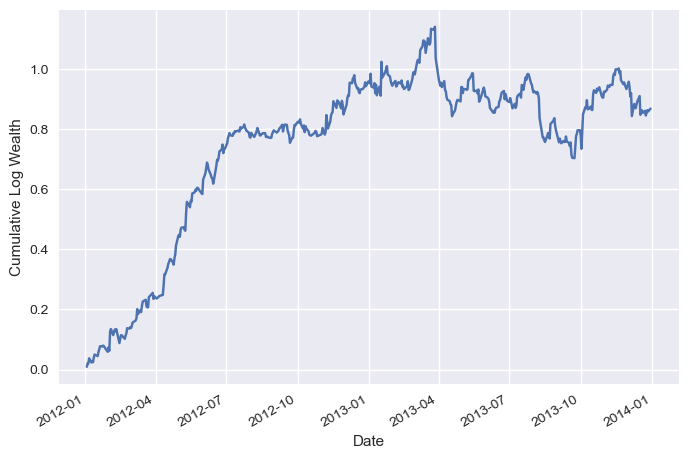

In [28]:
ar1_resids_cum_wealth['log_cum_wealth'].plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Log Wealth')
plt.show()

### Strategy 4: Directional positions based on residuals
In this strategy, we will use the AR(1) forecasted values to generate residuals. We will then go long asset $i$ if the residual is negative, and go short asset $i$ if the residual is positive. Note that this assumes the returns are mean-reverting, but it is time-series mean-reversion. The previous strategy involved 

In [29]:
# Assign positions based on the negative residual
ar1_resid_ts = directional_positions(all_forecasts_resids, 'residual')
# Calculate the returns
ar1_resid_ts_ret = position_returns(ar1_resid_ts, 'weight', 'forward_return')
ar1_resid_ts_date_ret = date_returns(ar1_resid_ts_ret, 'positions_return')
ar1_resid_ts_wealth = calculate_wealth(ar1_resid_ts_date_ret, 'positions_return')
ar1_resid_ts_log_w = cum_log_wealth(ar1_resid_ts_wealth, 'wealth')
ar1_resid_ts_cum_w = cum_simple_wealth(ar1_resid_ts_log_w ,'wealth')
ar1_resid_ts_sr = calculate_sr(ar1_resid_ts_date_ret, 'positions_return')
print('Daily SR:', ar1_resid_ts_sr)

Daily SR: 0.04339359590722107


In [30]:
ar1_resid_ts_cum_w

,positions_return,wealth,log_cum_wealth,cum_wealth
date,,,,
2012-01-03,-0.002003,0.997997,-0.002005,0.997997
2012-01-04,0.004703,1.004703,0.002687,1.002691
2012-01-05,-0.011484,0.988516,-0.008864,0.991175
2012-01-06,0.018862,1.018862,0.009822,1.009871
2012-01-09,0.010014,1.010014,0.019787,1.019984
...,...,...,...,...
2013-12-23,-0.003587,0.996413,0.278806,1.321550
2013-12-24,0.000142,1.000142,0.278947,1.321738
2013-12-26,-0.000453,0.999547,0.278494,1.321139


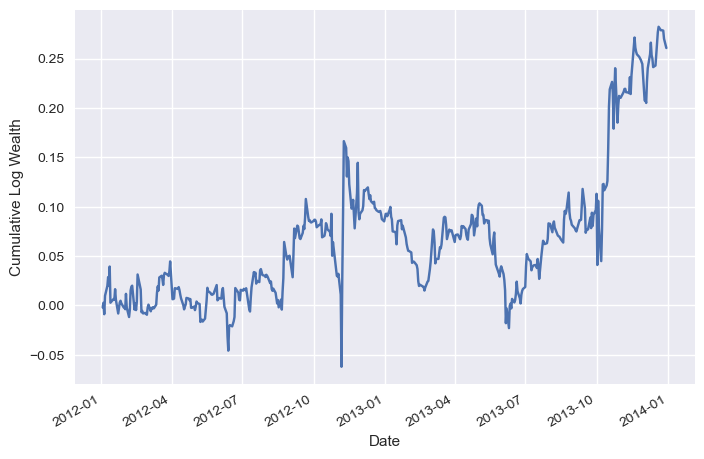

In [31]:
ar1_resid_ts_cum_w['log_cum_wealth'].plot()
plt.xlabel('Date')
plt.ylabel('Cumulative Log Wealth')
plt.show()